In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd 
import fastf1
import fastf1.plotting

# Enable Matplotlib patches for plotting timedelta values and load
fastf1.plotting.setup_mpl(mpl_timedelta_support=True, misc_mpl_mods=False)



c:\Users\noehu\anaconda3\Lib\site-packages\fastf1\plotting\_plotting.py:90: FutureWarning: FastF1 will no longer silently modify the default Matplotlib colors in the future.
To remove this warning, explicitly set `color_scheme=None` or `color_scheme='fastf1'` when calling `.setup_mpl()`.
  warnings.warn(


In [3]:
# This plot is intended for practice sessions only — it selects quick laps and filters out those where the driver is conserving tires or energy.

def practice_session_graph(year, gp, id, comp=True):
    session = fastf1.get_session(year, gp, id)
    session.load()

    driver_laps = session.laps.pick_drivers(session.drivers).pick_quicklaps()
    driver_laps = driver_laps.reset_index()
    driver_laps

    # create the figure
    fig, ax = plt.subplots(figsize=(20, 8))
    fig.patch.set_facecolor('#2c3e50')
    ax.set_facecolor('#2c3e50')  

    # Seaborn doesn't have proper timedelta support,
    # so we have to convert timedelta to float (in seconds)
    driver_laps["LapTime(s)"] = driver_laps["LapTime"].dt.total_seconds()
    driver_order = driver_laps.groupby("Driver")["LapTime(s)"].min().sort_values().index

    sns.boxplot(data=driver_laps,
                x="Driver",
                y="LapTime(s)",
                hue="Driver",
                order=driver_order,
                palette=fastf1.plotting.get_driver_color_mapping(session=session)
                )
    
    if comp == True:
        sns.swarmplot(data=driver_laps,
                    x="Driver",
                    y="LapTime(s)",
                    hue="Compound",
                    order=driver_order,
                    palette=fastf1.plotting.get_compound_mapping(session=session),
                    hue_order=["SOFT", "MEDIUM", "HARD"],
                    linewidth=0,
                    size=4,
                    )

    plt.title(session, fontsize=18, color='white')
    ax.set_xlabel("Driver", fontsize=14, color="white")  # X-axis label in white
    ax.set_ylabel("Lap Time (s)", fontsize=14, color="white")  # Y-axis label in white
    ax.tick_params(axis='x', colors='white')  # Rotate x-axis labels and set to white
    ax.tick_params(axis='y', colors='white')  # Y-axis (timings) in white

    plt.show()

In [7]:
# This plot is designed to compare the performance of drivers from the same team.

def practice_teammate_comparison(year, gp, id):
   # Loading the GP
   session = fastf1.get_session(year, gp, id)
   session.load()

   # Creating a DF with the quick laps & a list of teams to be used as filters later  
   df = session.laps.pick_drivers(session.drivers).pick_quicklaps()
   df["LapTime(s)"] = df["LapTime"].dt.total_seconds()

   # **Sort teams by their FASTEST lap time**
   team_order = df.groupby("Team")["LapTime(s)"].min().sort_values().index.tolist()
#    df_teams = df['Team'].drop_duplicates()
#    teams = [team for team in df_teams]

   # **Find Global Min & Max Lap Time**
   min_time = df["LapTime(s)"].min()
   max_time = df["LapTime(s)"].max()

   # **Apply Buffer ±1 sec**
   min_time -= 1
   max_time += 1

   # Create a single figure with 2 rows and 5 columns
   fig, axs = plt.subplots(nrows=2, ncols=5, figsize=(20, 10))
   fig.suptitle(f'{session} - Team Comparison', fontsize=18)  
   axs = axs.flatten()  # Flatten the grid to iterate easily over subplots
   first_legend = None  # Placeholder to store the first legend
   fig.patch.set_facecolor('#283747')
#    axs.set_facecolor('#283747')

   # Creating new DFs per team, to be used for the charts
   for i, team in enumerate(team_order):
       ax = axs[i]  # Select subplot for the current team
       ax.set_facecolor('#283747')
       team_df = df[df['Team'] == team]

       # Boxplot for lap times per driver
       sns.boxplot(
           data=team_df, 
           x="Driver", 
           y="LapTime(s)", 
           hue="Driver", 
           palette=fastf1.plotting.get_driver_color_mapping(session=session), 
           ax=ax
       )

       # Swarmplot for tire compounds
       swarm = sns.swarmplot(
           data=team_df, 
           x="Driver", 
           y="LapTime(s)", 
           hue="Compound", 
           palette=fastf1.plotting.get_compound_mapping(session=session), 
           hue_order=["SOFT", "MEDIUM", "HARD"], 
           linewidth=0, 
           size=4, 
           ax=ax
       )

       # **Set consistent y-axis limits**
       ax.set_ylim(min_time, max_time)

       # Store the first legend and remove others
       if first_legend is None:
           first_legend = ax.legend(loc='upper right', title="Compound")  # Store first legend
       else:
           ax.legend_.remove()  # Remove legends from other subplots

   plt.tight_layout()  # Adjust layout
   plt.show()

In [31]:
session = fastf1.get_session(year, gp, id)
session.load()

d_fastest_lap = {}

for driver in session.drivers:
     
    df = session.laps.pick_drivers(driver).pick_fastest().reset_index(drop=True)
    d_fastest_lap.update({df.iloc[1]: df.iloc[3].total_seconds()})

driver_fastest_lap = pd.DataFrame(d_fastest_lap.items(), columns=['Driver', 'BestTime'])
driver_fastest_lap = driver_fastest_lap.sort_values('BestTime').reset_index(drop=True)
driver_fastest_lap

core           INFO 	Loading data for Chinese Grand Prix - Practice 1 [v3.5.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
core        WARNING 	No result data for this session available on Ergast! (This is expected for recent sessions)


req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '4', '5', '6', '7', '10', '12', '14', '16', '18', '22', '23', '27', '30', '31', '44', '55', '63', '81', '87']


,Driver,BestTime
0,NOR,91.504
1,LEC,91.958
2,PIA,92.153
3,HAM,92.195
4,RUS,92.377
5,HUL,92.507
6,ALB,92.687
7,ALO,92.766
8,ANT,92.874
9,TSU,92.934


core           INFO 	Loading data for Chinese Grand Prix - Practice 1 [v3.5.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info


core        WARNING 	No result data for this session available on Ergast! (This is expected for recent sessions)
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '4', '5', '6', '7', '10', '12', '14', '16', '18', '22', '23', '27', '30', '31', '44', '55', '63', '81', '87']
C:\Users\noehu\AppData\Local\Temp\ipykernel_24148\3639404541.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,

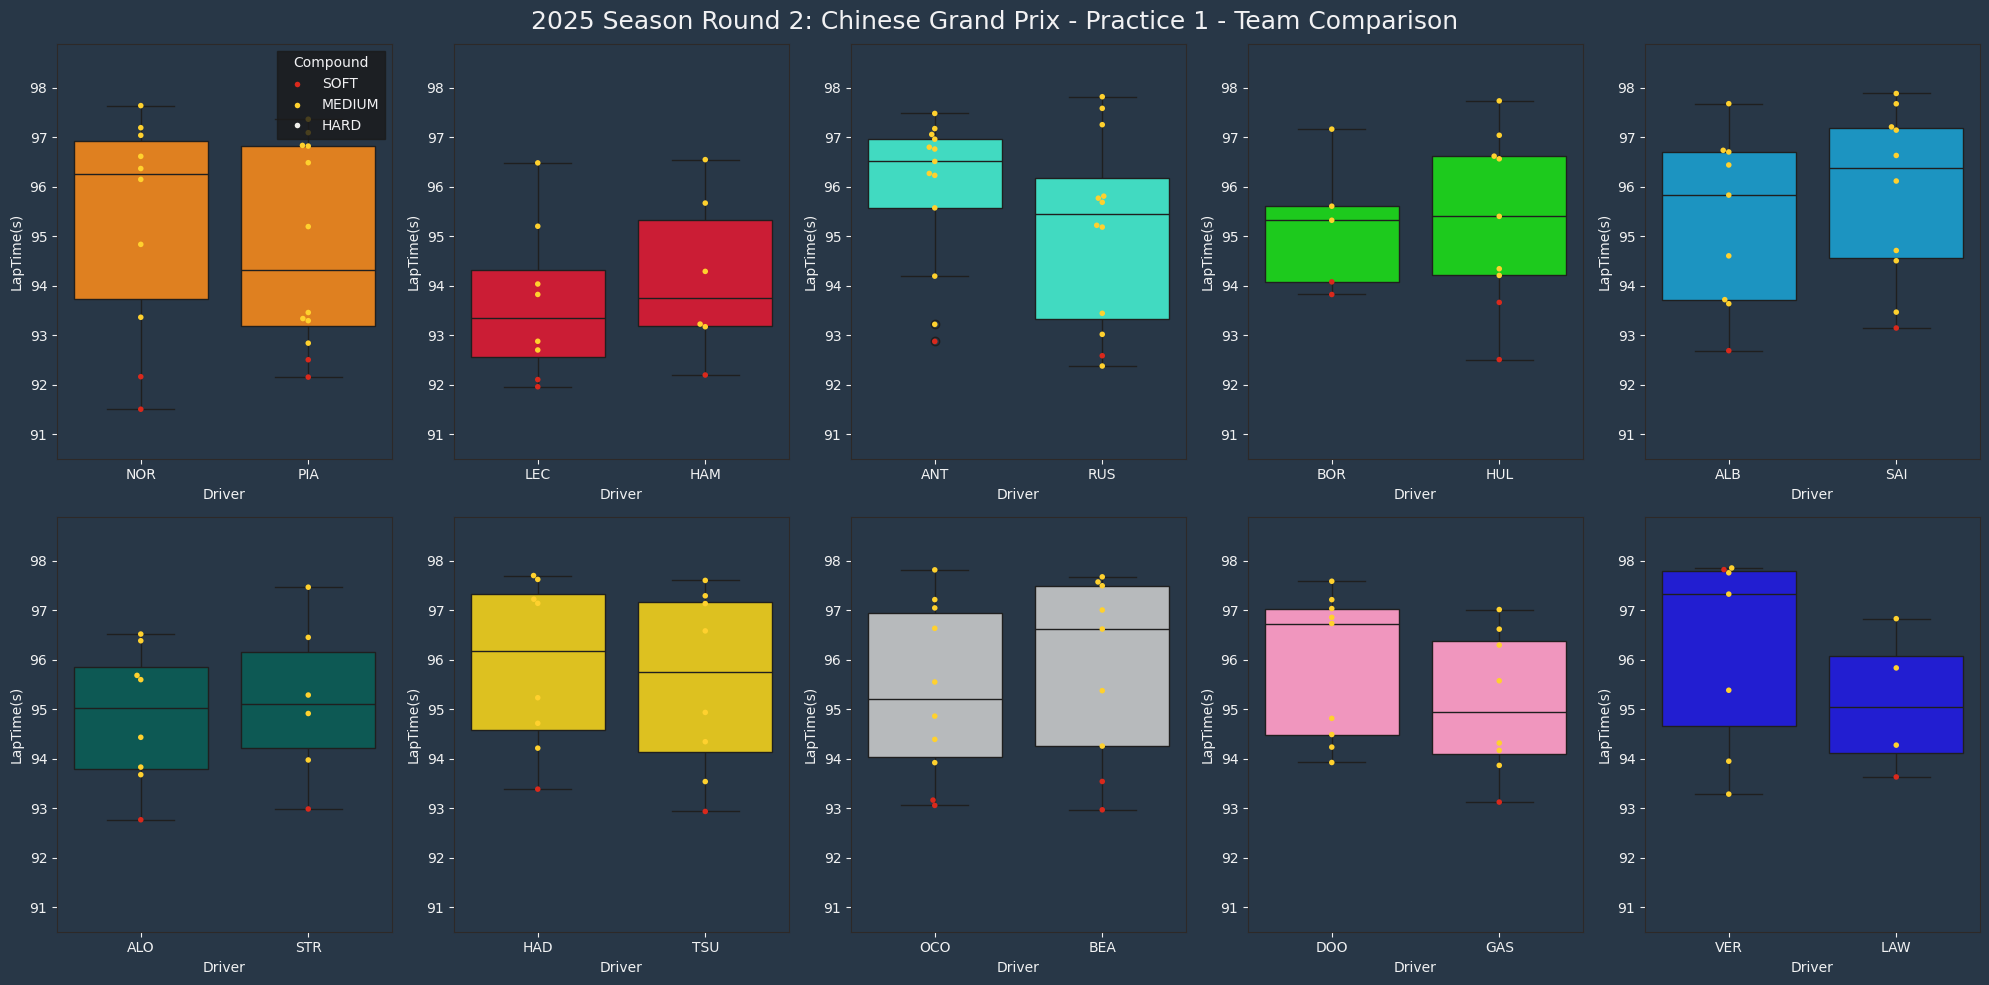

In [8]:
year = 2025
gp = 'China'
id = 'FP1'

practice_teammate_comparison(year, gp, id)

In [ ]:
# This can be used to generate all charts immediately after the session ends. 
# *** It's important to include all plots. *** 

import time

year = 2025
gp = 'China'
id = 'FP1'

while True:
    try:
        practice_teammate_comparison(year, gp, id)
        break  # Exit the loop if it succeeds
    except Exception as e:
        print(f"Error: {e}. Retrying in 5 minutes...")
        time.sleep(300)


req         WARNING 	DEFAULT CACHE ENABLED! (602.06 MB) C:\Users\noehu\AppData\Local\Temp\fastf1


core           INFO 	Loading data for Chinese Grand Prix - Practice 1 [v3.5.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
core        WARNING 	No result data for this session available on Ergast! (This is expected for recent sessions)
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '4', '5', '6', '7', '10', '12', '14', '16', '18', '22', '23', '27', '30', '31', '44', '55', '63', '81', '87

Error: name 'teams' is not defined. Retrying in 5 minutes...
